In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    PrecisionRecallDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# Neural Network & Autoencoder (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

print("All libraries loaded.")
print(f"TensorFlow version: {tf.__version__}")

2026-04-11 12:25:31.495540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775910331.675176      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775910331.729681      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775910332.152312      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775910332.152351      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775910332.152354      55 computation_placer.cc:177] computation placer alr

All libraries loaded.
TensorFlow version: 2.19.0


## Data Loading & Quality Checks

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Rate: {df['Class'].mean()*100:.4f}%")
print(f"\nData Types:\n{df.dtypes}")

DATASET OVERVIEW
Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.1727%

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
# ── NULL CHECK ──────────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
print("=" * 50)
print("NULL VALUE CHECK")
print("=" * 50)
if null_counts.sum() == 0:
    print("✅ No null values found.")
else:
    print(f"⚠️  Nulls detected:\n{null_counts[null_counts > 0]}")
    df = df.dropna()
    print(f"Removed rows with nulls. New shape: {df.shape}")

# ── DUPLICATE CHECK ─────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"\n{'=' * 50}")
print("DUPLICATE ROW CHECK")
print("=" * 50)
if dup_count == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️  Found {dup_count} duplicate rows — removing them.")
    df = df.drop_duplicates()
    print(f"Cleaned shape: {df.shape}")
    print(f"\nClass distribution after cleaning:")
    print(df['Class'].value_counts())

NULL VALUE CHECK
✅ No null values found.

DUPLICATE ROW CHECK
⚠️  Found 1081 duplicate rows — removing them.
Cleaned shape: (283726, 31)

Class distribution after cleaning:
Class
0    283253
1       473
Name: count, dtype: int64


## Exploratory Visualizations

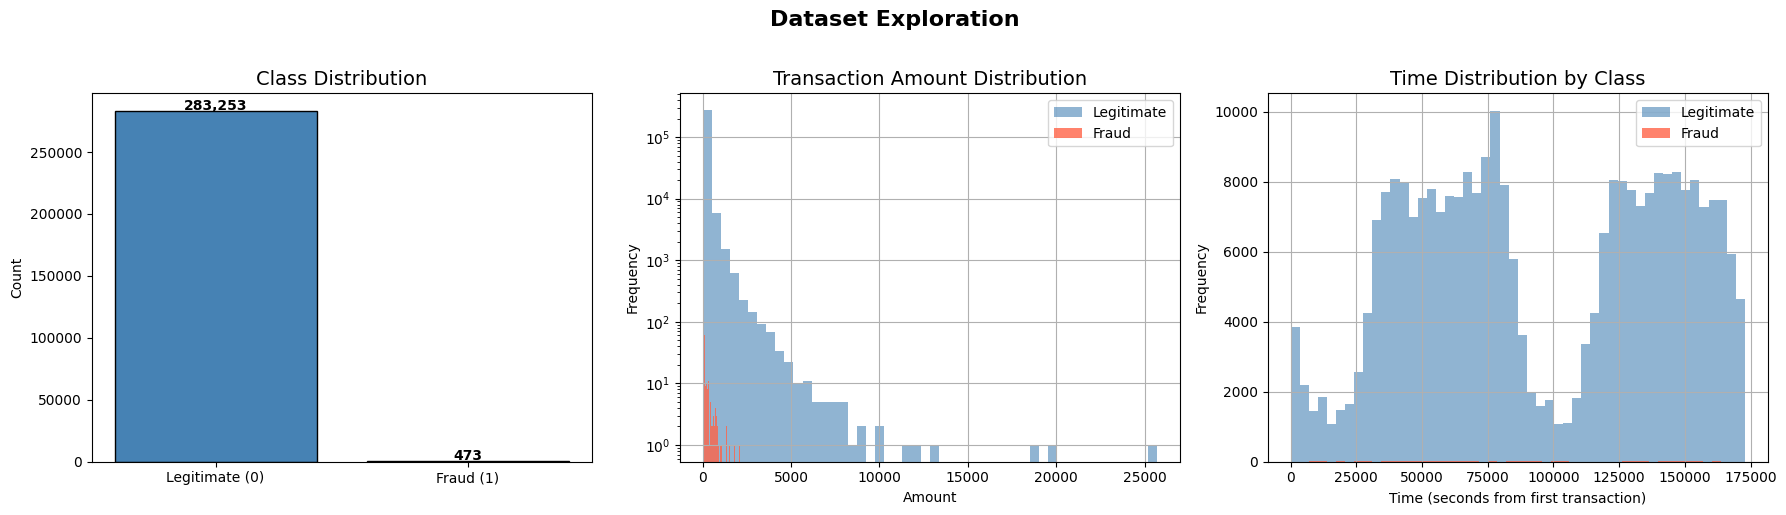

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Transaction Amount distribution by class
df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.6, label='Legitimate',
                                    color='steelblue', ax=axes[1])
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.8, label='Fraud',
                                    color='tomato', ax=axes[1])
axes[1].set_title('Transaction Amount Distribution', fontsize=14)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_yscale('log')

# Time distribution by class
df[df['Class'] == 0]['Time'].hist(bins=50, alpha=0.6, label='Legitimate',
                                   color='steelblue', ax=axes[2])
df[df['Class'] == 1]['Time'].hist(bins=50, alpha=0.8, label='Fraud',
                                   color='tomato', ax=axes[2])
axes[2].set_title('Time Distribution by Class', fontsize=14)
axes[2].set_xlabel('Time (seconds from first transaction)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Dataset Exploration', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [5]:
df = df.copy()

scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

# Keep raw Time for time-based split, then drop original Amount/Time
df_with_time = df.drop(['Amount'], axis=1)  # keep Time for split ordering
df = df.drop(['Amount', 'Time'], axis=1)

print("Features after preprocessing:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")

Features after preprocessing:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']

Dataset shape: (283726, 31)


## 5. Time-Based Train / Test Split

Using the raw `Time` column to respect temporal ordering — the model trains on earlier transactions and tests on later ones. This is more realistic than a random split for fraud detection.

In [6]:
# Sort by original Time to ensure temporal ordering
df_sorted = df_with_time.sort_values('Time').reset_index(drop=True)

# 80% train / 20% test — time-ordered
split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

# Drop raw Time now
feature_cols = [c for c in df.columns if c != 'Class']

X_train = train_df[feature_cols]
y_train = train_df['Class']
X_test  = test_df[feature_cols]
y_test  = test_df['Class']

print("=" * 50)
print("TIME-BASED SPLIT")
print("=" * 50)
print(f"Train size : {len(X_train):,}  |  Fraud: {y_train.sum()}  ({y_train.mean()*100:.3f}%)")
print(f"Test size  : {len(X_test):,}   |  Fraud: {y_test.sum()}  ({y_test.mean()*100:.3f}%)")

TIME-BASED SPLIT
Train size : 226,980  |  Fraud: 399  (0.176%)
Test size  : 56,746   |  Fraud: 74  (0.130%)


## Handling Class Imbalance

In [7]:
# ── SMOTE ────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE resampled distribution:")
print(pd.Series(y_train_smote).value_counts())

# ── COST-SENSITIVE weights ───────────────────────────────────────────────────
# Scale weight inversely proportional to class frequency
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos   # used in XGBoost / LightGBM
class_weight_dict = {0: 1, 1: neg / pos}  # used in sklearn models

print(f"\nCost-Sensitive scale_pos_weight (neg/pos): {scale_pos_weight:.1f}")

SMOTE resampled distribution:
Class
0    226581
1    226581
Name: count, dtype: int64

Cost-Sensitive scale_pos_weight (neg/pos): 567.9


## Model Training

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- Neural Network (MLP)
- Autoencoder (anomaly detection — train only on legitimate transactions)

In [8]:
# ── HELPER: store all results ────────────────────────────────────────────────
results = {}   # results[model_name][strategy] = metrics_dict

def store_metrics(name, strategy, y_true, y_pred, y_proba):
    ap   = average_precision_score(y_true, y_proba)
    auc  = roc_auc_score(y_true, y_proba)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    if name not in results:
        results[name] = {}
    results[name][strategy] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'AUPRC': ap, 'ROC-AUC': auc,
        'F1': f1, 'Precision': prec, 'Recall': rec
    }
    return results[name][strategy]

print("Helper ready.")

Helper ready.


In [9]:
# ── LOGISTIC REGRESSION ──────────────────────────────────────────────────────
print("Training Logistic Regression...")

# No balancing
lr_none = LogisticRegression(max_iter=1000, random_state=42)
lr_none.fit(X_train, y_train)
store_metrics('Logistic Regression', 'No Balancing',
              y_test, lr_none.predict(X_test),
              lr_none.predict_proba(X_test)[:, 1])

# SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
store_metrics('Logistic Regression', 'SMOTE',
              y_test, lr_smote.predict(X_test),
              lr_smote.predict_proba(X_test)[:, 1])

# Cost-Sensitive
lr_cs = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_cs.fit(X_train, y_train)
store_metrics('Logistic Regression', 'Cost-Sensitive',
              y_test, lr_cs.predict(X_test),
              lr_cs.predict_proba(X_test)[:, 1])

print(" Logistic Regression done.")

Training Logistic Regression...
 Logistic Regression done.


In [10]:
# ── RANDOM FOREST ────────────────────────────────────────────────────────────
print("Training Random Forest...")

rf_none = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_none.fit(X_train, y_train)
store_metrics('Random Forest', 'No Balancing',
              y_test, rf_none.predict(X_test),
              rf_none.predict_proba(X_test)[:, 1])

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
store_metrics('Random Forest', 'SMOTE',
              y_test, rf_smote.predict(X_test),
              rf_smote.predict_proba(X_test)[:, 1])

rf_cs = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_cs.fit(X_train, y_train)
store_metrics('Random Forest', 'Cost-Sensitive',
              y_test, rf_cs.predict(X_test),
              rf_cs.predict_proba(X_test)[:, 1])

print(" Random Forest done.")

Training Random Forest...
 Random Forest done.


In [11]:
# ── XGBOOST ──────────────────────────────────────────────────────────────────
print("Training XGBoost...")

xgb_none = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                               max_depth=6, use_label_encoder=False,
                               eval_metric='aucpr', random_state=42,
                               tree_method='hist')
xgb_none.fit(X_train, y_train)
store_metrics('XGBoost', 'No Balancing',
              y_test, xgb_none.predict(X_test),
              xgb_none.predict_proba(X_test)[:, 1])

xgb_smote = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=6, use_label_encoder=False,
                                eval_metric='aucpr', random_state=42,
                                tree_method='hist')
xgb_smote.fit(X_train_smote, y_train_smote)
store_metrics('XGBoost', 'SMOTE',
              y_test, xgb_smote.predict(X_test),
              xgb_smote.predict_proba(X_test)[:, 1])

xgb_cs = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                             max_depth=6, use_label_encoder=False,
                             eval_metric='aucpr', random_state=42,
                             scale_pos_weight=scale_pos_weight,
                             tree_method='hist')
xgb_cs.fit(X_train, y_train)
store_metrics('XGBoost', 'Cost-Sensitive',
              y_test, xgb_cs.predict(X_test),
              xgb_cs.predict_proba(X_test)[:, 1])

print(" XGBoost done.")

Training XGBoost...
 XGBoost done.


In [12]:
# ── LIGHTGBM ─────────────────────────────────────────────────────────────────
print("Training LightGBM...")

lgb_none = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=6, random_state=42, verbose=-1)
lgb_none.fit(X_train, y_train)
store_metrics('LightGBM', 'No Balancing',
              y_test, lgb_none.predict(X_test),
              lgb_none.predict_proba(X_test)[:, 1])

lgb_smote = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=6, random_state=42, verbose=-1)
lgb_smote.fit(X_train_smote, y_train_smote)
store_metrics('LightGBM', 'SMOTE',
              y_test, lgb_smote.predict(X_test),
              lgb_smote.predict_proba(X_test)[:, 1])

lgb_cs = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                              max_depth=6, random_state=42, verbose=-1,
                              scale_pos_weight=scale_pos_weight)
lgb_cs.fit(X_train, y_train)
store_metrics('LightGBM', 'Cost-Sensitive',
              y_test, lgb_cs.predict(X_test),
              lgb_cs.predict_proba(X_test)[:, 1])

print(" LightGBM done.")

Training LightGBM...
 LightGBM done.


In [13]:
# ── NEURAL NETWORK (MLP) ─────────────────────────────────────────────────────
print("Training Neural Network (MLP)...")

def build_mlp(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

input_dim = X_train.shape[1]

# No balancing
nn_none = build_mlp(input_dim)
nn_none.fit(X_train, y_train, epochs=15, batch_size=2048,
            validation_split=0.1, verbose=0)
nn_none_proba = nn_none.predict(X_test, verbose=0).flatten()
nn_none_pred = (nn_none_proba >= 0.5).astype(int)
store_metrics('Neural Network', 'No Balancing', y_test, nn_none_pred, nn_none_proba)

# SMOTE
nn_smote = build_mlp(input_dim)
nn_smote.fit(X_train_smote, y_train_smote, epochs=15, batch_size=2048,
             validation_split=0.1, verbose=0)
nn_smote_proba = nn_smote.predict(X_test, verbose=0).flatten()
nn_smote_pred = (nn_smote_proba >= 0.5).astype(int)
store_metrics('Neural Network', 'SMOTE', y_test, nn_smote_pred, nn_smote_proba)

# Cost-Sensitive (via class_weight in fit)
pos_weight = neg / pos
nn_cs = build_mlp(input_dim)
nn_cs.fit(X_train, y_train, epochs=15, batch_size=2048,
          class_weight={0: 1, 1: pos_weight},
          validation_split=0.1, verbose=0)
nn_cs_proba = nn_cs.predict(X_test, verbose=0).flatten()
nn_cs_pred = (nn_cs_proba >= 0.5).astype(int)
store_metrics('Neural Network', 'Cost-Sensitive', y_test, nn_cs_pred, nn_cs_proba)

print(" Neural Network done.")

Training Neural Network (MLP)...


I0000 00:00:1775910694.619689      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1775910698.208308     202 service.cc:152] XLA service 0x7dbdbc002ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775910698.208357     202 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775910698.679472     202 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775910701.168802     202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 Neural Network done.


In [14]:
# ── AUTOENCODER (Anomaly Detection) ─────────────────────────────────────────
# Train ONLY on legitimate transactions, then flag high-reconstruction-error as fraud
print("Training Autoencoder...")

X_train_legit = X_train[y_train == 0]

def build_autoencoder(input_dim):
    inp = layers.Input(shape=(input_dim,))
    # Encoder
    encoded = layers.Dense(32, activation='relu')(inp)
    encoded = layers.Dense(16, activation='relu')(encoded)
    encoded = layers.Dense(8,  activation='relu')(encoded)
    # Decoder
    decoded = layers.Dense(16, activation='relu')(encoded)
    decoded = layers.Dense(32, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)
    ae = Model(inp, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae

ae = build_autoencoder(input_dim)
ae.fit(X_train_legit, X_train_legit,
       epochs=20, batch_size=256,
       validation_split=0.1, verbose=0)

# Reconstruction error on test set = anomaly score
X_test_arr = X_test.values
X_test_reconstructed = ae.predict(X_test_arr, verbose=0)
reconstruction_errors = np.mean(np.power(X_test_arr - X_test_reconstructed, 2), axis=1)

# Use a threshold at the 95th percentile of legitimate errors on train
X_train_legit_arr = X_train_legit.values
train_reconstructed = ae.predict(X_train_legit_arr, verbose=0)
train_errors = np.mean(np.power(X_train_legit_arr - train_reconstructed, 2), axis=1)
ae_threshold = np.percentile(train_errors, 95)

ae_pred = (reconstruction_errors > ae_threshold).astype(int)
# Normalise errors to [0,1] range for AUPRC / ROC-AUC
ae_proba = (reconstruction_errors - reconstruction_errors.min()) / \
           (reconstruction_errors.max() - reconstruction_errors.min() + 1e-10)

store_metrics('Autoencoder', 'No Balancing', y_test, ae_pred, ae_proba)
store_metrics('Autoencoder', 'SMOTE', y_test, ae_pred, ae_proba)       # same model, shown for completeness
store_metrics('Autoencoder', 'Cost-Sensitive', y_test, ae_pred, ae_proba)

print(f"Autoencoder threshold (95th pct): {ae_threshold:.6f}")
print(" Autoencoder done.")

Training Autoencoder...
Autoencoder threshold (95th pct): 0.434131
 Autoencoder done.


## 8. Evaluation

In [15]:
# ── FULL EVALUATION FUNCTION ─────────────────────────────────────────────────
def evaluate_model(name, strategy, show_plots=True):
    m = results[name][strategy]
    y_pred  = m['y_pred']
    y_proba = m['y_proba']
    y_true  = y_test

    print(f"\n{'='*60}")
    print(f"  {name}  |  Strategy: {strategy}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                 target_names=['Legitimate', 'Fraud']))
    print(f"  AUPRC  : {m['AUPRC']:.4f}")
    print(f"  ROC-AUC: {m['ROC-AUC']:.4f}")

    if not show_plots:
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'], ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Precision-Recall Curve
    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_proba)
    axes[1].plot(rec_arr, prec_arr, lw=2, color='darkorange',
                 label=f'AUPRC = {m["AUPRC"]:.4f}')
    axes[1].fill_between(rec_arr, prec_arr, alpha=0.2, color='darkorange')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[2].plot(fpr, tpr, lw=2, color='steelblue',
                 label=f'ROC-AUC = {m["ROC-AUC"]:.4f}')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[2].fill_between(fpr, tpr, alpha=0.2, color='steelblue')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('ROC Curve')
    axes[2].legend()
    axes[2].set_xlim([0, 1])
    axes[2].set_ylim([0, 1])

    plt.suptitle(f"{name} — {strategy}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


  Logistic Regression  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56672
       Fraud       0.07      0.89      0.12        74

    accuracy                           0.98     56746
   macro avg       0.53      0.94      0.56     56746
weighted avg       1.00      0.98      0.99     56746

  AUPRC  : 0.7608
  ROC-AUC: 0.9862


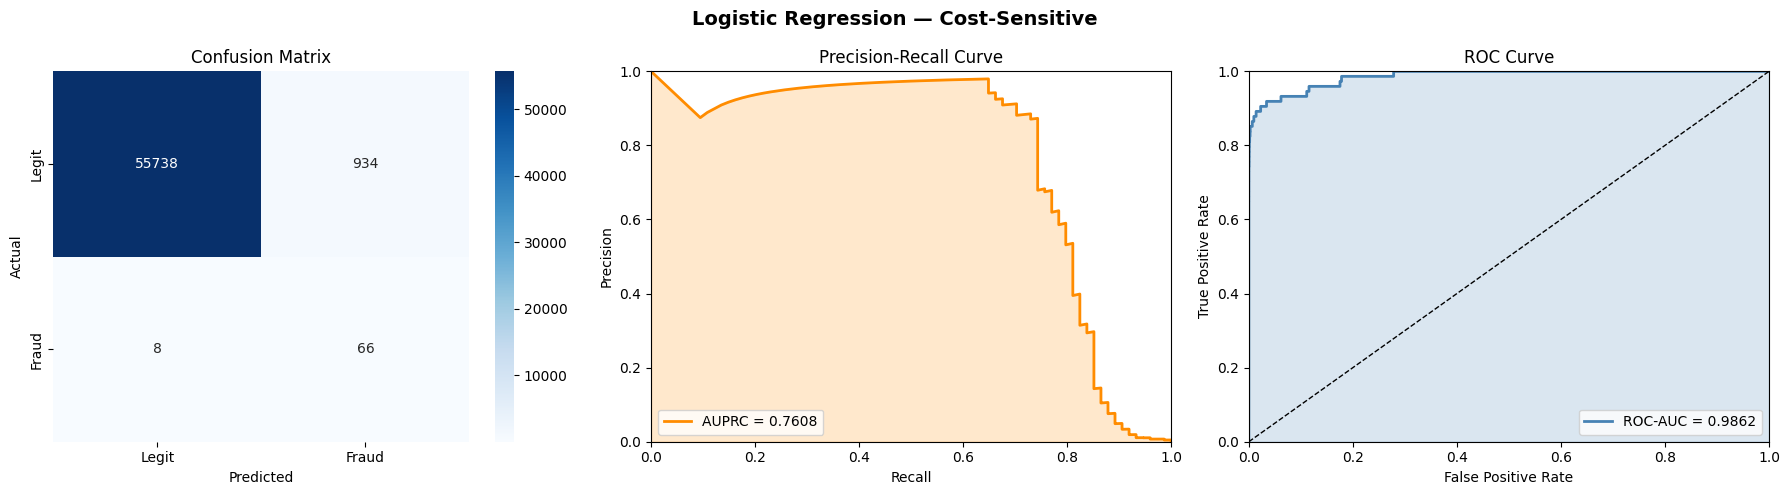


  Random Forest  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56672
       Fraud       0.98      0.65      0.78        74

    accuracy                           1.00     56746
   macro avg       0.99      0.82      0.89     56746
weighted avg       1.00      1.00      1.00     56746

  AUPRC  : 0.7994
  ROC-AUC: 0.9374


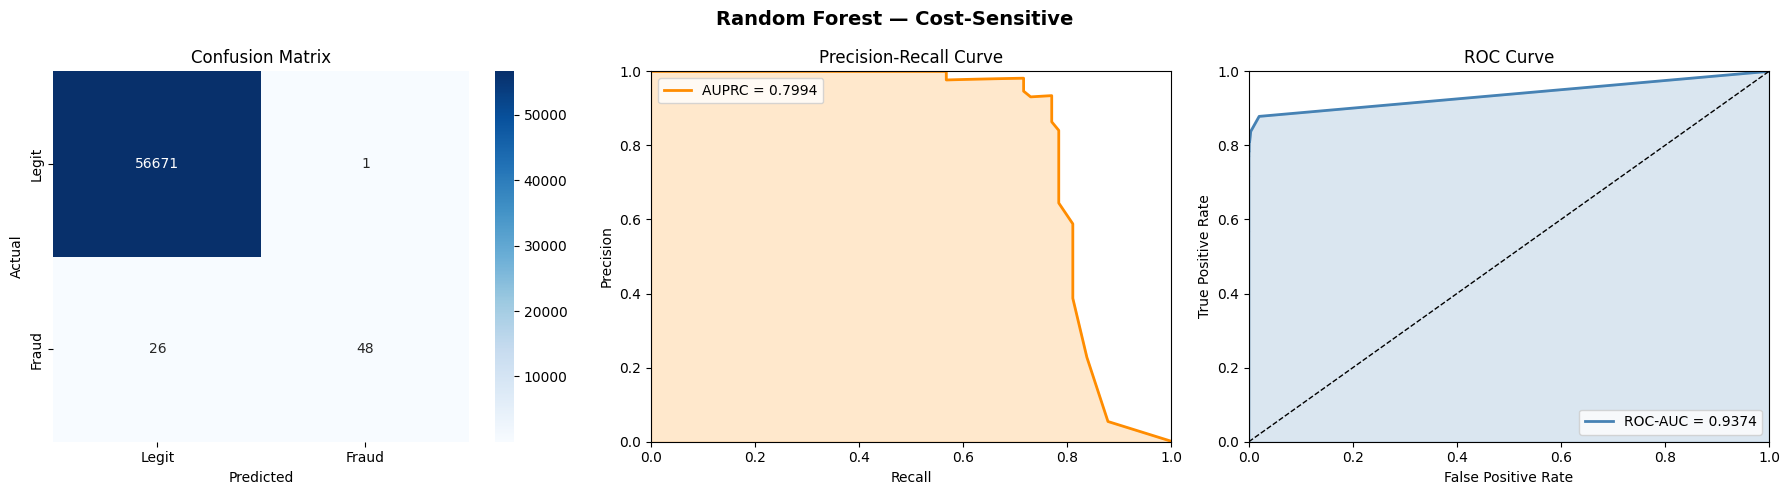


  XGBoost  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56672
       Fraud       0.81      0.74      0.77        74

    accuracy                           1.00     56746
   macro avg       0.90      0.87      0.89     56746
weighted avg       1.00      1.00      1.00     56746

  AUPRC  : 0.7923
  ROC-AUC: 0.9808


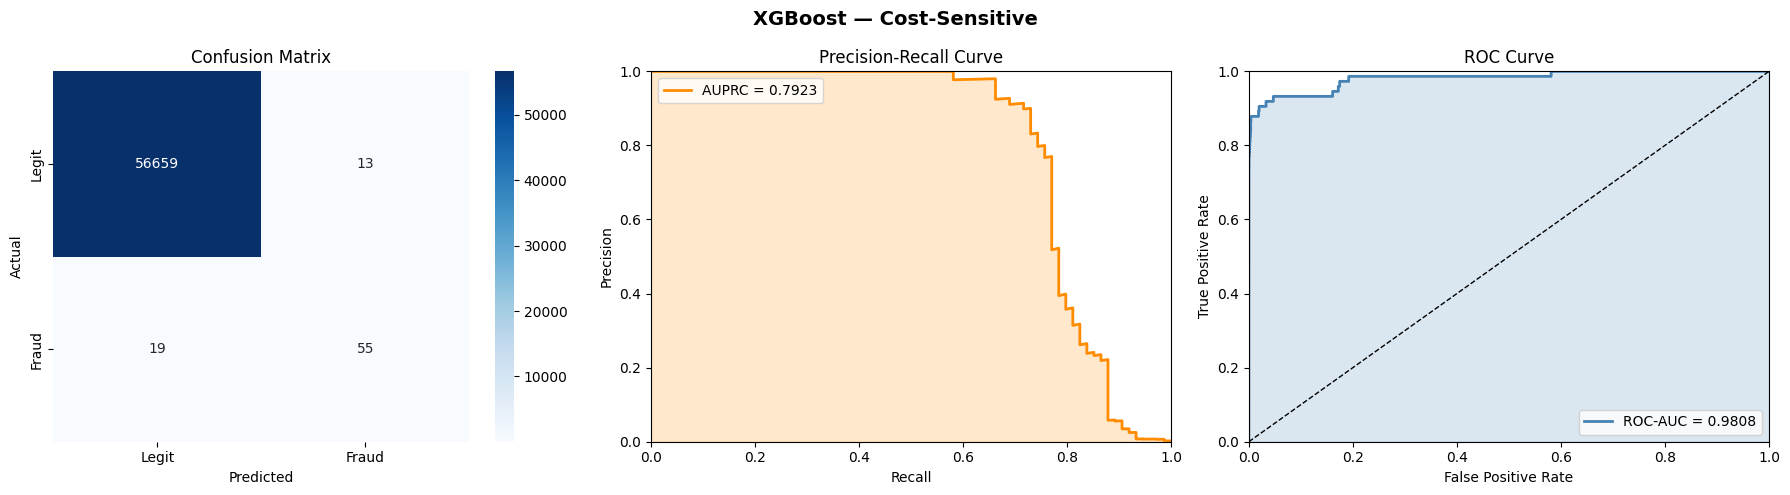


  LightGBM  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56672
       Fraud       0.06      0.59      0.11        74

    accuracy                           0.99     56746
   macro avg       0.53      0.79      0.55     56746
weighted avg       1.00      0.99      0.99     56746

  AUPRC  : 0.0374
  ROC-AUC: 0.7958


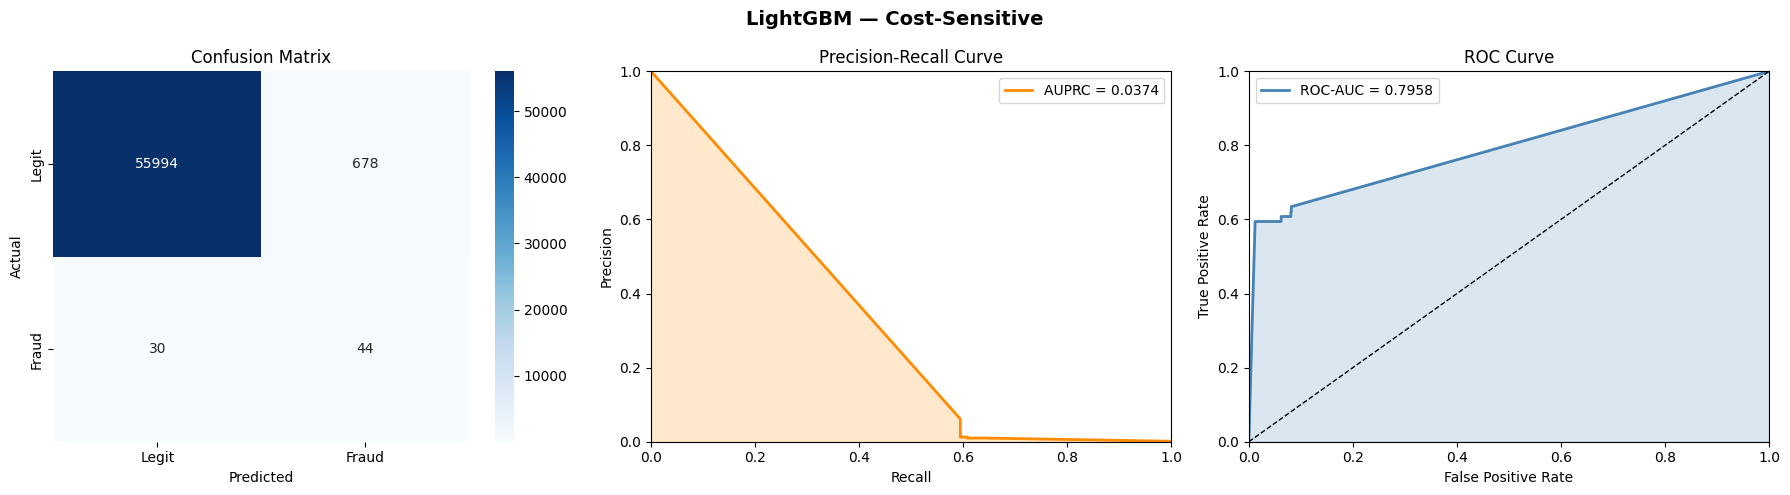


  Neural Network  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56672
       Fraud       0.12      0.89      0.22        74

    accuracy                           0.99     56746
   macro avg       0.56      0.94      0.61     56746
weighted avg       1.00      0.99      0.99     56746

  AUPRC  : 0.7629
  ROC-AUC: 0.9889


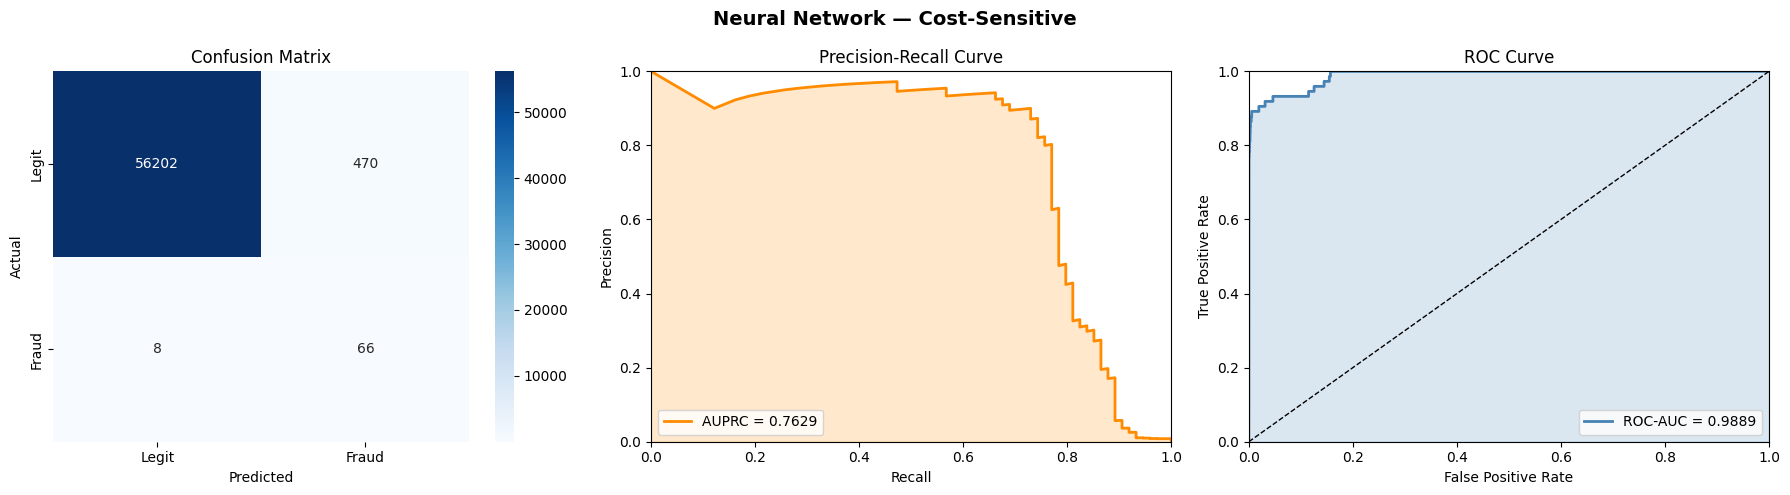


  Autoencoder  |  Strategy: Cost-Sensitive
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96     56672
       Fraud       0.02      0.82      0.03        74

    accuracy                           0.93     56746
   macro avg       0.51      0.88      0.50     56746
weighted avg       1.00      0.93      0.96     56746

  AUPRC  : 0.1015
  ROC-AUC: 0.9053


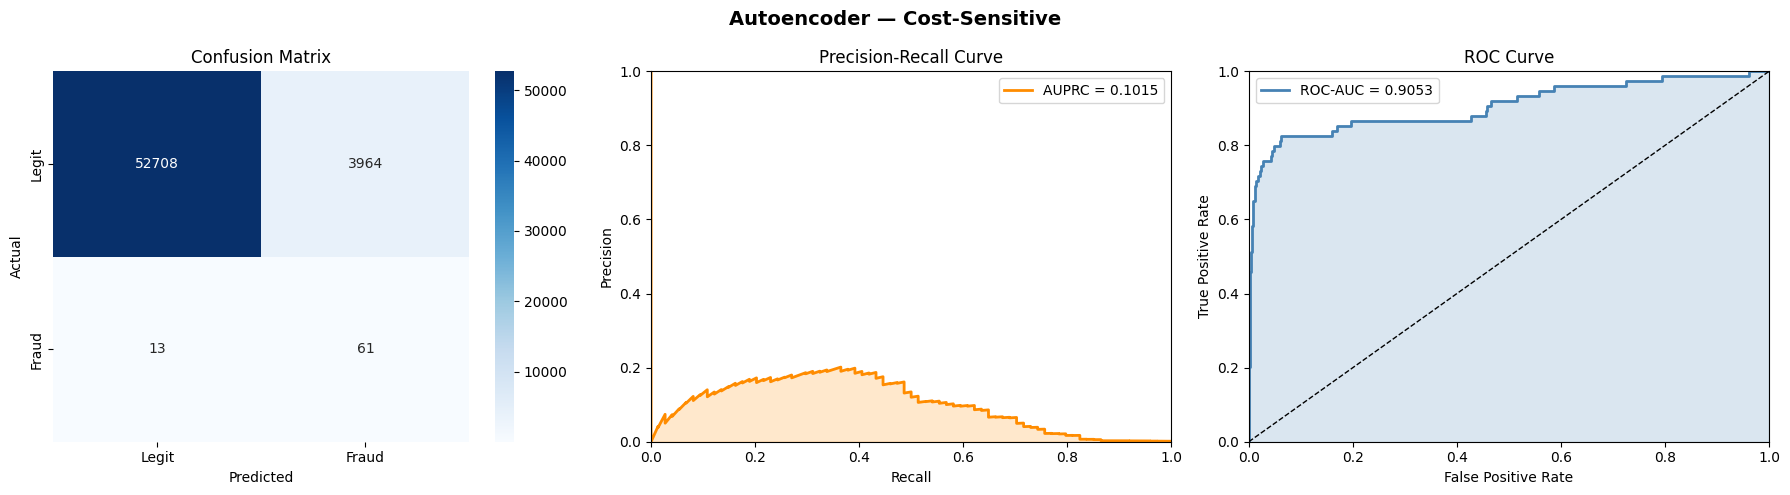

In [16]:
# Evaluate all models for Cost-Sensitive strategy (representative)
for model_name in ['Logistic Regression', 'Random Forest',
                   'XGBoost', 'LightGBM', 'Neural Network', 'Autoencoder']:
    evaluate_model(model_name, 'Cost-Sensitive')

## Cost-Based Evaluation

In fraud detection the cost of a **False Negative** (missing a fraud) is much higher than a **False Positive** (flagging a legitimate transaction).

We use a simple cost model:
- **False Negative cost** = average fraudulent transaction amount (the bank absorbs the loss)
- **False Positive cost** = fixed investigation cost per flagged transaction

In [19]:
# Cost assumptions (in USD)
# Read original amounts before scaling/dropping
df_original = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
AVG_FRAUD_AMOUNT = df_original[df_original['Class'] == 1]['Amount'].mean()
FP_INVESTIGATION  = 5.0    # cost of investigating a false positive alert

print(f"Average fraud amount  : ${AVG_FRAUD_AMOUNT:.2f}")
print(f"FP investigation cost : ${FP_INVESTIGATION:.2f}")
print()

def compute_cost(y_true, y_pred, fn_cost=AVG_FRAUD_AMOUNT, fp_cost=FP_INVESTIGATION):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * fp_cost + fn * fn_cost
    # Savings = fraud caught * avg amount - investigation costs
    savings = tp * fn_cost - fp * fp_cost
    return {
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Total_Cost': total_cost,
        'Net_Savings': savings
    }

cost_rows = []
for model_name, strategies in results.items():
    for strategy, m in strategies.items():
        if model_name == 'Autoencoder' and strategy != 'No Balancing':
            continue  # autoencoder same model across strategies
        c = compute_cost(y_test, m['y_pred'])
        cost_rows.append({
            'Model': model_name,
            'Strategy': strategy,
            'TP': c['TP'], 'FP': c['FP'], 'FN': c['FN'],
            'Net Savings ($)': round(c['Net_Savings'], 2),
            'Total Cost ($)': round(c['Total_Cost'], 2),
            'AUPRC': round(m['AUPRC'], 4),
            'ROC-AUC': round(m['ROC-AUC'], 4),
            'F1': round(m['F1'], 4)
        })

cost_df = pd.DataFrame(cost_rows)
print(cost_df.sort_values('Net Savings ($)', ascending=False).to_string(index=False))

Average fraud amount  : $122.21
FP investigation cost : $5.00

              Model       Strategy  TP   FP  FN  Net Savings ($)  Total Cost ($)  AUPRC  ROC-AUC     F1
     Neural Network          SMOTE  56    7  18          6808.83         2234.80 0.7895   0.9683 0.8175
     Neural Network   No Balancing  55    7  19          6686.62         2357.02 0.8174   0.9852 0.8088
            XGBoost Cost-Sensitive  55   13  19          6656.62         2387.02 0.7923   0.9808 0.7746
           LightGBM          SMOTE  56   46  18          6613.83         2429.80 0.7590   0.9748 0.6364
      Random Forest          SMOTE  54    1  20          6594.41         2449.23 0.8176   0.9734 0.8372
            XGBoost          SMOTE  56   51  18          6588.83         2454.80 0.7665   0.9813 0.6188
      Random Forest   No Balancing  52    2  22          6344.99         2698.65 0.7794   0.9363 0.8125
            XGBoost   No Balancing  52    3  22          6339.99         2703.65 0.8047   0.9847 0.8062
 

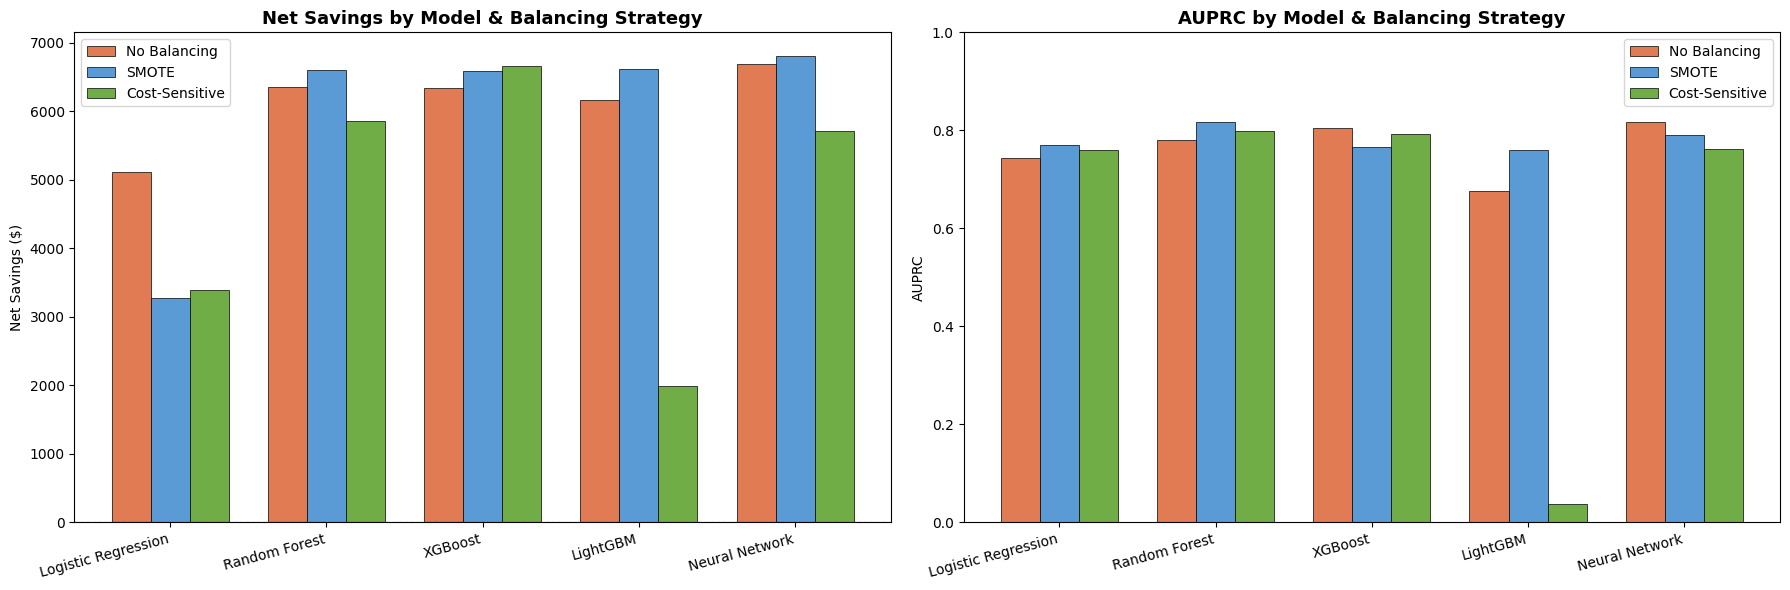

In [20]:
# Visualise Net Savings by model & strategy
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df = cost_df[cost_df['Model'] != 'Autoencoder'].copy()

# Net Savings heatmap-style bar chart
strategies_order = ['No Balancing', 'SMOTE', 'Cost-Sensitive']
colors = {'No Balancing': '#e07b54', 'SMOTE': '#5b9bd5', 'Cost-Sensitive': '#70ad47'}

models = plot_df['Model'].unique()
x = np.arange(len(models))
width = 0.25

for i, strat in enumerate(strategies_order):
    vals = [plot_df[(plot_df['Model'] == m) & (plot_df['Strategy'] == strat)]['Net Savings ($)'].values
            for m in models]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    axes[0].bar(x + i * width, vals, width, label=strat,
                color=colors[strat], edgecolor='black', linewidth=0.5)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_title('Net Savings by Model & Balancing Strategy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Net Savings ($)')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# AUPRC comparison
for i, strat in enumerate(strategies_order):
    vals = [plot_df[(plot_df['Model'] == m) & (plot_df['Strategy'] == strat)]['AUPRC'].values
            for m in models]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    axes[1].bar(x + i * width, vals, width, label=strat,
                color=colors[strat], edgecolor='black', linewidth=0.5)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_title('AUPRC by Model & Balancing Strategy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUPRC')
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Comparison — All Models × All Strategies

In [21]:
# Full comparison table
all_rows = []
for model_name, strategies in results.items():
    for strategy, m in strategies.items():
        all_rows.append({
            'Model': model_name,
            'Strategy': strategy,
            'AUPRC': round(m['AUPRC'], 4),
            'ROC-AUC': round(m['ROC-AUC'], 4),
            'F1': round(m['F1'], 4),
            'Precision': round(m['Precision'], 4),
            'Recall': round(m['Recall'], 4),
        })

comparison_df = pd.DataFrame(all_rows)
comparison_df = comparison_df.sort_values(['AUPRC', 'F1'], ascending=False)
print(comparison_df.to_string(index=False))

              Model       Strategy  AUPRC  ROC-AUC     F1  Precision  Recall
      Random Forest          SMOTE 0.8176   0.9734 0.8372     0.9818  0.7297
     Neural Network   No Balancing 0.8174   0.9852 0.8088     0.8871  0.7432
            XGBoost   No Balancing 0.8047   0.9847 0.8062     0.9455  0.7027
      Random Forest Cost-Sensitive 0.7994   0.9374 0.7805     0.9796  0.6486
            XGBoost Cost-Sensitive 0.7923   0.9808 0.7746     0.8088  0.7432
     Neural Network          SMOTE 0.7895   0.9683 0.8175     0.8889  0.7568
      Random Forest   No Balancing 0.7794   0.9363 0.8125     0.9630  0.7027
Logistic Regression          SMOTE 0.7693   0.9851 0.1201     0.0644  0.8919
            XGBoost          SMOTE 0.7665   0.9813 0.6188     0.5234  0.7568
     Neural Network Cost-Sensitive 0.7629   0.9889 0.2164     0.1231  0.8919
Logistic Regression Cost-Sensitive 0.7608   0.9862 0.1229     0.0660  0.8919
           LightGBM          SMOTE 0.7590   0.9748 0.6364     0.5490  0.7568

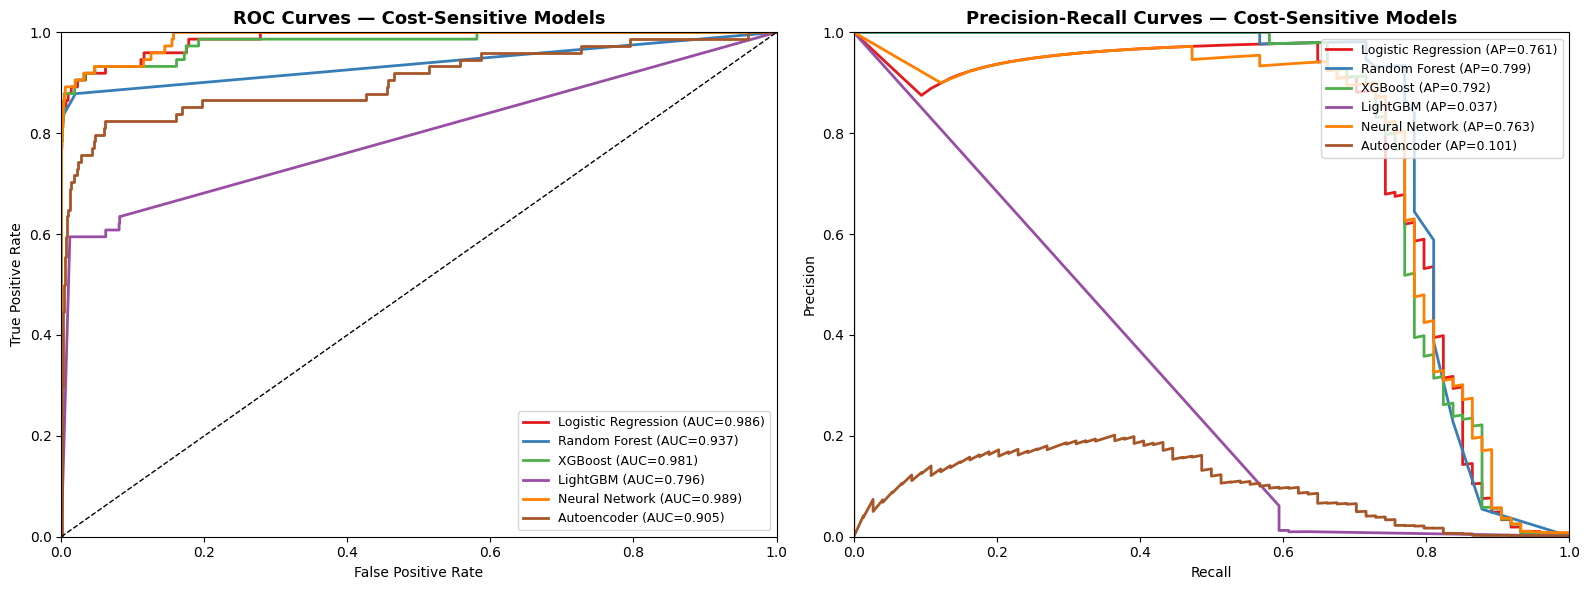

In [22]:
# ── VISUAL COMPARISON: ROC & PR Curves overlay (Cost-Sensitive only) ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

model_colors = {
    'Logistic Regression': '#e41a1c',
    'Random Forest':       '#377eb8',
    'XGBoost':             '#4daf4a',
    'LightGBM':            '#984ea3',
    'Neural Network':      '#ff7f00',
    'Autoencoder':         '#a65628',
}

strategy = 'Cost-Sensitive'

for model_name, color in model_colors.items():
    key = strategy if model_name != 'Autoencoder' else 'No Balancing'
    m = results[model_name][key]
    y_proba = m['y_proba']

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax1.plot(fpr, tpr, lw=2, color=color,
             label=f"{model_name} (AUC={m['ROC-AUC']:.3f})")

    # PR
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    ax2.plot(rec_arr, prec_arr, lw=2, color=color,
             label=f"{model_name} (AP={m['AUPRC']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curves — Cost-Sensitive Models', fontsize=13, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

ax2.set_title('Precision-Recall Curves — Cost-Sensitive Models', fontsize=13, fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

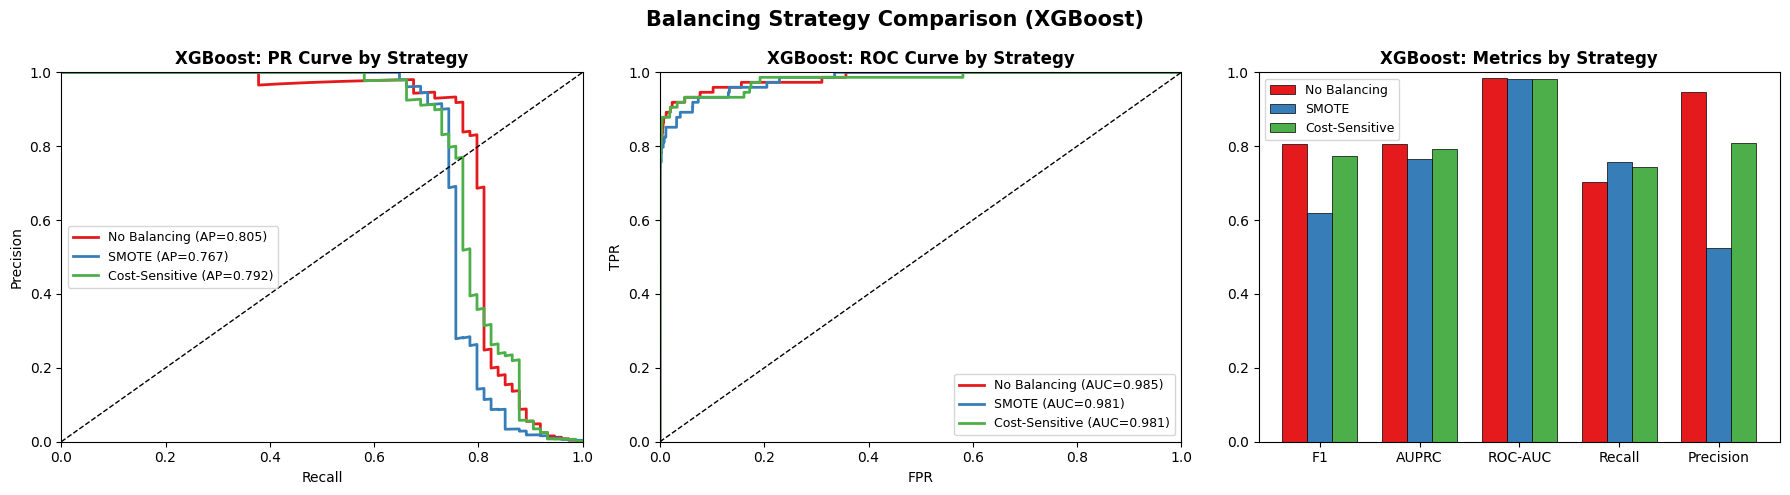

In [23]:
# ── BALANCING STRATEGY COMPARISON (XGBoost as example) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategy_colors = {
    'No Balancing':   '#e41a1c',
    'SMOTE':          '#377eb8',
    'Cost-Sensitive': '#4daf4a',
}

focus_model = 'XGBoost'
for strategy, color in strategy_colors.items():
    m = results[focus_model][strategy]

    # PR
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, m['y_proba'])
    axes[0].plot(rec_arr, prec_arr, lw=2, color=color,
                 label=f"{strategy} (AP={m['AUPRC']:.3f})")

    # ROC
    fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f"{strategy} (AUC={m['ROC-AUC']:.3f})")

    # Confusion Matrix
    cm = confusion_matrix(y_test, m['y_pred'])

for ax in axes[:2]:
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=9)

axes[0].set_title(f'{focus_model}: PR Curve by Strategy', fontweight='bold')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

axes[1].set_title(f'{focus_model}: ROC Curve by Strategy', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# Metric bar comparison
metrics = ['F1', 'AUPRC', 'ROC-AUC', 'Recall', 'Precision']
x = np.arange(len(metrics))
width = 0.25
for i, (strategy, color) in enumerate(strategy_colors.items()):
    m = results[focus_model][strategy]
    vals = [m['F1'], m['AUPRC'], m['ROC-AUC'], m['Recall'], m['Precision']]
    axes[2].bar(x + i * width, vals, width, label=strategy, color=color,
                edgecolor='black', linewidth=0.5)

axes[2].set_xticks(x + width)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim([0, 1])
axes[2].set_title(f'{focus_model}: Metrics by Strategy', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Balancing Strategy Comparison (XGBoost)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

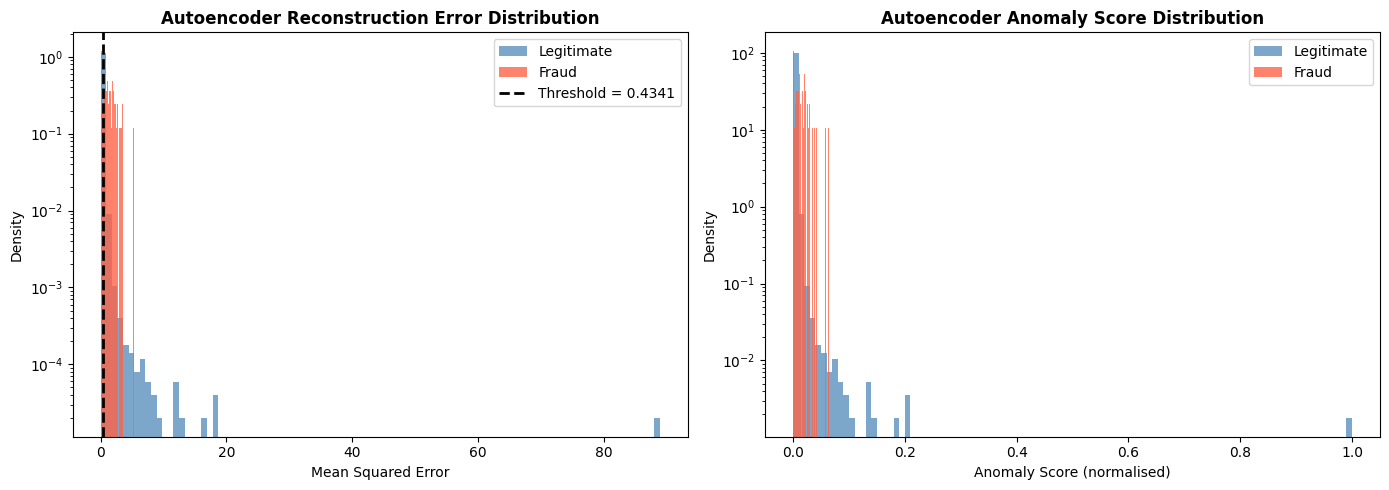

In [24]:
# ── AUTOENCODER: Reconstruction Error Distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_errors = reconstruction_errors[y_test.values == 0]
fraud_errors = reconstruction_errors[y_test.values == 1]

axes[0].hist(legit_errors, bins=100, alpha=0.7, label='Legitimate', color='steelblue', density=True)
axes[0].hist(fraud_errors, bins=50,  alpha=0.8, label='Fraud',      color='tomato',    density=True)
axes[0].axvline(ae_threshold, color='black', linestyle='--', lw=2, label=f'Threshold = {ae_threshold:.4f}')
axes[0].set_title('Autoencoder Reconstruction Error Distribution', fontweight='bold')
axes[0].set_xlabel('Mean Squared Error')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_yscale('log')

# Score distribution (normalised)
axes[1].hist(ae_proba[y_test.values == 0], bins=100, alpha=0.7,
             label='Legitimate', color='steelblue', density=True)
axes[1].hist(ae_proba[y_test.values == 1], bins=50,  alpha=0.8,
             label='Fraud',      color='tomato',    density=True)
axes[1].set_title('Autoencoder Anomaly Score Distribution', fontweight='bold')
axes[1].set_xlabel('Anomaly Score (normalised)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

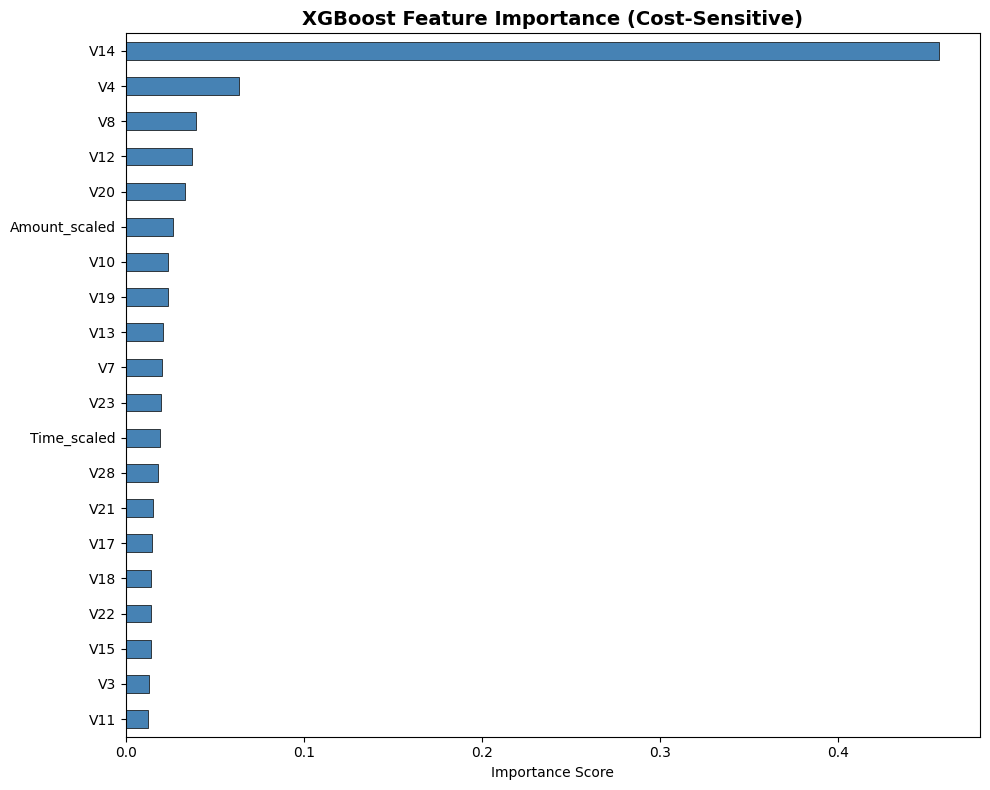

In [25]:
# ── FEATURE IMPORTANCE (XGBoost) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

feature_imp = pd.Series(xgb_cs.feature_importances_, index=feature_cols)
feature_imp = feature_imp.sort_values(ascending=True).tail(20)
feature_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('XGBoost Feature Importance (Cost-Sensitive)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Save Best Model

In [26]:
# Pick best model by AUPRC
best_row = comparison_df.iloc[0]
print(f"Best model: {best_row['Model']}  |  Strategy: {best_row['Strategy']}")
print(f"AUPRC: {best_row['AUPRC']}  |  ROC-AUC: {best_row['ROC-AUC']}  |  F1: {best_row['F1']}")

# Save XGBoost cost-sensitive as the primary production model
xgb_cs.save_model("fraud_model_xgb.json")
joblib.dump(scaler_amount, "scaler_amount.pkl")
joblib.dump(scaler_time,   "scaler_time.pkl")

print("\n Model and scalers saved.")

Best model: Random Forest  |  Strategy: SMOTE
AUPRC: 0.8176  |  ROC-AUC: 0.9734  |  F1: 0.8372

 Model and scalers saved.
